This notebook will be used to analyze raw single particle tracks generated with TrackMate from organoid timecourse Batch20220930_D14.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline


import sys
sys.path.append("..")

pd.set_option('display.max_columns', None) # Displays all columns of df

In [64]:
# Reads in csv files "spots" from tracking

D14_pos14_ROI1_spots = pd.read_csv('/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos14_1_w1conf561-488dual_ROI-1_raw_spots.csv')
D14_pos14_ROI2_spots = pd.read_csv('/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos14_1_w1conf561-488dual_ROI-2_raw_spots.csv')
D14_pos14_ROI3_spots = pd.read_csv('/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos14_1_w1conf561-488dual_ROI-3_raw_spots.csv')

D14_pos19_ROI1_spots = pd.read_csv('/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos19_1_w1conf561-488dual_ROI-1_raw_spots.csv')
D14_pos19_ROI2_spots = pd.read_csv('/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos19_1_w1conf561-488dual_ROI-2_raw_spots.csv')
D14_pos19_ROI3_spots = pd.read_csv('/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos19_1_w1conf561-488dual_ROI-3_raw_spots.csv')

D14_pos19_ROI3_spots.head()

,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,VISIBILITY,MANUAL_INTEGER_SPOT_FEATURE,MANUAL_DOUBLE_SPOT_FEATURE,HAS_MAX_QUALITY_IN_FRAME,MANUAL_SPOT_COLOR,MEAN_INTENSITY_CH1,MEDIAN_INTENSITY_CH1,MIN_INTENSITY_CH1,MAX_INTENSITY_CH1,TOTAL_INTENSITY_CH1,STD_INTENSITY_CH1,CONTRAST_CH1,SNR_CH1
0,Label,Spot ID,Track ID,Quality,X,Y,Z,T,Frame,Radius,Visibility,Custom Integer Spot Feature,Custom Double Spot Feature,Has max quality,Manual spot color,Mean intensity ch1,Median intensity ch1,Min intensity ch1,Max intensity ch1,Sum intensity ch1,Std intensity ch1,Contrast ch1,Signal/Noise ratio ch1
1,Label,Spot ID,Track ID,Quality,X,Y,Z,T,Frame,R,Visibility,Integer Spot Feature,Double Spot Feature,Max Quality,Spot color,Mean ch1,Median ch1,Min ch1,Max ch1,Sum ch1,Std ch1,Ctrst ch1,SNR ch1
2,NaN,NaN,NaN,(quality),(micron),(micron),(micron),(sec),NaN,(micron),NaN,NaN,NaN,NaN,NaN,(counts),(counts),(counts),(counts),(counts),(counts),NaN,NaN
3,ID105761,105761,0,11534.533203125,108.93366809999999,62.26702262999999,0.0,0.0,0,0.20172901499999998,1,NaN,NaN,0,NaN,15915.857142857143,15252.0,8598.0,24272.0,334233.0,4351.384047469429,0.13753177933653937,0.8844476577078015
4,ID106014,106014,0,6682.880859375,108.66469607999998,62.53599464999999,0.0,0.05,1,0.20172901499999998,1,NaN,NaN,0,NaN,14163.333333333334,14123.0,8606.0,20132.0,297430.0,3091.535934342885,0.07787436637327697,0.6619840954501536


In [65]:
#Reads in csv files "tracks" from tracking

D14_pos14_ROI1_tracks = pd.read_csv('/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos14_1_w1conf561-488dual_ROI-1_raw_tracks.csv')
D14_pos14_ROI2_tracks = pd.read_csv('/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos14_1_w1conf561-488dual_ROI-2_raw_tracks.csv')
D14_pos14_ROI3_tracks = pd.read_csv('/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos14_1_w1conf561-488dual_ROI-3_raw_tracks.csv')

D14_pos19_ROI1_tracks = pd.read_csv('/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos19_1_w1conf561-488dual_ROI-1_raw_tracks.csv')
D14_pos19_ROI2_tracks = pd.read_csv('/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos19_1_w1conf561-488dual_ROI-2_raw_tracks.csv')
D14_pos19_ROI3_tracks = pd.read_csv('/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos19_1_w1conf561-488dual_ROI-3_raw_tracks.csv')


D14_pos14_ROI3_tracks.head()

,LABEL,TRACK_INDEX,TRACK_ID,MANUAL_INTEGER_TRACK_FEATURE,MANUAL_DOUBLE_TRACK_FEATURE,NUMBER_SPOTS,NUMBER_GAPS,NUMBER_SPLITS,NUMBER_MERGES,NUMBER_COMPLEX,LONGEST_GAP,TRACK_DURATION,TRACK_START,TRACK_STOP,TRACK_DISPLACEMENT,TRACK_X_LOCATION,TRACK_Y_LOCATION,TRACK_Z_LOCATION,TRACK_MEAN_SPEED,TRACK_MAX_SPEED,TRACK_MIN_SPEED,TRACK_MEDIAN_SPEED,TRACK_STD_SPEED,TRACK_MEAN_QUALITY,TOTAL_DISTANCE_TRAVELED,MAX_DISTANCE_TRAVELED,CONFINEMENT_RATIO,MEAN_STRAIGHT_LINE_SPEED,LINEARITY_OF_FORWARD_PROGRESSION,MEAN_DIRECTIONAL_CHANGE_RATE
0,Label,Track index,Track ID,Custom Integer Track Feature,Custom Double Track Feature,Number of spots in track,Number of gaps,Number of split events,Number of merge events,Number of complex points,Longest gap,Track duration,Track start,Track stop,Track displacement,Track mean X,Track mean Y,Track mean Z,Track mean speed,Track max speed,Track min speed,Track median speed,Track std speed,Track mean quality,Total distance traveled,Max distance traveled,Confinement ratio,Mean straight line speed,Linearity of forward progression,Mean directional change rate
1,Label,Index,ID,Integer Track Feature,Double Track Feature,N spots,N gaps,N splits,N merges,N complex,Lgst gap,Duration,Track start,Track stop,Track disp.,Track X,Track Y,Track Z,Mean sp.,Max speed,Min speed,Med. speed,Std speed,Mean Q,Total dist.,Max dist.,Cfn. ratio,Mn. v. line,Fwd. progr.,Mn. γ rate
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,(sec),(sec),(sec),(micron),(micron),(micron),(micron),(micron/sec),(micron/sec),(micron/sec),(micron/sec),(micron/sec),(quality),(micron),(micron),NaN,(micron/sec),NaN,(rad/sec)
3,Track_295,0,0,NaN,NaN,25,6,0,0,0,3,1.6,0.25,1.85,0.19019193929144845,79.1208094032,114.4314561888,0.0,2.2955129689617504,6.014397207654475,0.0,2.6897202000000653,1.7863074022309176,4029.0390625,3.332465387605401,0.484896204887575,0.057072442522235485,0.11886996205715528,0.05178361597796574,20.22536745227906
4,Track_296,1,1,NaN,NaN,4,1,0,0,0,3,0.30000000000000004,0.25,0.55,0.19019193929144845,78.3717223275,125.84528385749998,0.0,1.2679462619429887,3.8038387858289657,0.0,0.0,2.1961473469522925,3253.2368774414062,0.19019193929144845,0.19019193929144845,1.0,0.6339731309714948,0.5000000000000003,0.0


In [74]:
# Removes the first three rows to create a table that only contains values

D14_pos14_ROI1_spots_filtered = D14_pos14_ROI1_spots.drop(labels = [0,1,2], axis = 0, inplace = False).reset_index(drop=True)
D14_pos14_ROI2_spots_filtered = D14_pos14_ROI2_spots.drop(labels = [0,1,2], axis = 0, inplace = False).reset_index(drop=True)
D14_pos14_ROI3_spots_filtered = D14_pos14_ROI3_spots.drop(labels = [0,1,2], axis = 0, inplace = False).reset_index(drop=True)

D14_pos19_ROI1_spots_filtered = D14_pos19_ROI1_spots.drop(labels = [0,1,2], axis = 0, inplace = False).reset_index(drop=True)
D14_pos19_ROI2_spots_filtered = D14_pos19_ROI2_spots.drop(labels = [0,1,2], axis = 0, inplace = False).reset_index(drop=True)
D14_pos19_ROI3_spots_filtered = D14_pos19_ROI3_spots.drop(labels = [0,1,2], axis = 0, inplace = False).reset_index(drop=True)



D14_pos19_ROI3_spots_filtered.head()

,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,VISIBILITY,MANUAL_INTEGER_SPOT_FEATURE,MANUAL_DOUBLE_SPOT_FEATURE,HAS_MAX_QUALITY_IN_FRAME,MANUAL_SPOT_COLOR,MEAN_INTENSITY_CH1,MEDIAN_INTENSITY_CH1,MIN_INTENSITY_CH1,MAX_INTENSITY_CH1,TOTAL_INTENSITY_CH1,STD_INTENSITY_CH1,CONTRAST_CH1,SNR_CH1
0,ID105761,105761,0,11534.533203125,108.93366809999999,62.26702262999999,0.0,0.0,0,0.20172901499999998,1,NaN,NaN,0,NaN,15915.857142857143,15252.0,8598.0,24272.0,334233.0,4351.384047469429,0.13753177933653937,0.8844476577078015
1,ID106014,106014,0,6682.880859375,108.66469607999998,62.53599464999999,0.0,0.05,1,0.20172901499999998,1,NaN,NaN,0,NaN,14163.333333333334,14123.0,8606.0,20132.0,297430.0,3091.535934342885,0.07787436637327697,0.6619840954501536
2,ID106078,106078,0,10008.08984375,108.26123804999999,62.401508639999996,0.0,0.1,2,0.20172901499999998,1,NaN,NaN,0,NaN,12825.666666666666,12022.0,7306.0,19653.0,269339.0,3500.4931843003687,0.13951904282414263,0.8972069080872614
3,ID106052,106052,1,8266.6240234375,117.27180071999999,50.83571178,0.0,0.1,2,0.20172901499999998,1,NaN,NaN,0,NaN,10964.047619047618,10186.0,6651.0,16492.0,230245.0,2985.63037692529,0.128105880119305,0.8340346035008736
4,ID105860,105860,1,9703.5859375,116.59937066999998,50.56673976,0.0,0.2,4,0.20172901499999998,1,NaN,NaN,0,NaN,10938.809523809523,10726.0,6884.0,19294.0,229715.0,3542.8882090611837,0.15096757384412846,0.8099592955702208


In [97]:
# Removes the first three rows to create a table that only contains values

D14_pos14_ROI1_tracks_filtered = D14_pos14_ROI1_tracks.drop(labels = [0,1,2], axis = 0, inplace = False).reset_index(drop=True)
D14_pos14_ROI2_tracks_filtered = D14_pos14_ROI2_tracks.drop(labels = [0,1,2], axis = 0, inplace = False).reset_index(drop=True)
D14_pos14_ROI3_tracks_filtered = D14_pos14_ROI3_tracks.drop(labels = [0,1,2], axis = 0, inplace = False).reset_index(drop=True)

D14_pos19_ROI1_tracks_filtered = D14_pos19_ROI1_tracks.drop(labels = [0,1,2], axis = 0, inplace = False).reset_index(drop=True)
D14_pos19_ROI2_tracks_filtered = D14_pos19_ROI2_tracks.drop(labels = [0,1,2], axis = 0, inplace = False).reset_index(drop=True)
D14_pos19_ROI3_tracks_filtered = D14_pos19_ROI3_tracks.drop(labels = [0,1,2], axis = 0, inplace = False).reset_index(drop=True)



D14_pos19_ROI3_tracks_filtered.head()

,LABEL,TRACK_INDEX,TRACK_ID,MANUAL_INTEGER_TRACK_FEATURE,MANUAL_DOUBLE_TRACK_FEATURE,NUMBER_SPOTS,NUMBER_GAPS,NUMBER_SPLITS,NUMBER_MERGES,NUMBER_COMPLEX,LONGEST_GAP,TRACK_DURATION,TRACK_START,TRACK_STOP,TRACK_DISPLACEMENT,TRACK_X_LOCATION,TRACK_Y_LOCATION,TRACK_Z_LOCATION,TRACK_MEAN_SPEED,TRACK_MAX_SPEED,TRACK_MIN_SPEED,TRACK_MEDIAN_SPEED,TRACK_STD_SPEED,TRACK_MEAN_QUALITY,TOTAL_DISTANCE_TRAVELED,MAX_DISTANCE_TRAVELED,CONFINEMENT_RATIO,MEAN_STRAIGHT_LINE_SPEED,LINEARITY_OF_FORWARD_PROGRESSION,MEAN_DIRECTIONAL_CHANGE_RATE
0,Track_285,0,0,NaN,NaN,3,0,0,0,0,0,0.1,0.0,0.1,0.6857467892952377,108.61986740999998,62.401508639999996,0.0,8.056659836110681,8.505642100563524,7.607677571657838,8.505642100563524,0.6349568076541937,9408.501302083334,0.8056659836110681,0.6857467892952377,0.8511551973705757,6.857467892952377,0.8511551973705757,22.14297435588144
1,Track_286,1,1,NaN,NaN,11,1,0,0,0,2,0.6000000000000001,0.0,0.6000000000000001,1.2178226162414014,116.83166468727272,50.64009576545454,0.0,5.760890480180915,9.697924097751185,2.6897202000000653,5.379440400000136,3.0054978069756344,7457.50390625,3.163966643442576,1.371493578590474,0.3849037469359478,2.0297043604023353,0.3523247607961112,32.01749255923729
2,Track_287,2,2,NaN,NaN,30,0,0,0,0,0,1.4500000000000002,0.0,1.4500000000000002,1.4296058960728906,109.75851562799997,62.123570886,0.0,4.462411998496629,12.028794415308724,0.0,3.8038387858288694,2.7457130464203963,8958.260725911457,6.470497397820112,2.5267627254372726,0.22094219473058127,0.9859351007399244,0.22094219473058124,22.31148074007535
3,Track_288,3,3,NaN,NaN,7,0,0,0,0,0,0.30000000000000004,0.0,0.30000000000000004,0.3007198603827177,119.96152091999998,46.34003658857142,0.0,4.517693152176557,9.697924097751104,0.0,6.014397207654165,3.417822709089991,11088.530203683036,1.3553079456529673,0.4252821050281784,0.22188304978750442,1.0023995346090588,0.22188304978750442,21.201566335729076
4,Track_289,4,4,NaN,NaN,3,0,0,0,0,0,0.1,0.0,0.1,0.26897202000000675,107.85778001999999,63.56705406,0.0,3.803838785828969,3.803838785828969,3.803838785828969,3.803838785828969,0.0,6490.717610677083,0.3803838785828969,0.26897202000000675,0.7071067811865476,2.6897202000000675,0.7071067811865476,31.41592653589793


In [93]:
# Selects frames by value of 'FRAME'; table values need to be converted to type 'integer' first

D14_pos19_ROI3_spots_filtered['FRAME'] = D14_pos19_ROI3_spots_filtered['FRAME'].astype(int)
D14_pos19_ROI3_spots_tracks1020 = D14_pos19_ROI3_spots_filtered.loc[D14_pos19_ROI3_spots_filtered['FRAME'].isin([10,11,12,13,14,15,16,17,18,19,20])]
D14_pos19_ROI3_spots_tracks1020.head(20)

,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,VISIBILITY,MANUAL_INTEGER_SPOT_FEATURE,MANUAL_DOUBLE_SPOT_FEATURE,HAS_MAX_QUALITY_IN_FRAME,MANUAL_SPOT_COLOR,MEAN_INTENSITY_CH1,MEDIAN_INTENSITY_CH1,MIN_INTENSITY_CH1,MAX_INTENSITY_CH1,TOTAL_INTENSITY_CH1,STD_INTENSITY_CH1,CONTRAST_CH1,SNR_CH1
8,ID106457,106457,1,3055.77001953125,116.33039864999999,50.83571178,0.0,0.6000000000000001,12,0.20172901499999998,1,NaN,NaN,0,NaN,8012.619047619048,8026.0,6114.0,11087.0,168265.0,1368.888252422033,0.06381700817469697,0.7022730537955926
12,ID106221,106221,1,5152.06884765625,116.19591263999999,50.70122576999999,0.0,0.55,11,0.20172901499999998,1,NaN,NaN,0,NaN,9415.809523809523,9524.0,5447.0,13114.0,197732.0,1894.8963723393324,0.12493617432835476,1.1037291598011718
14,ID106307,106307,2,8461.091796875,109.74058416,61.72907858999999,0.0,0.5,10,0.20172901499999998,1,NaN,NaN,0,NaN,10927.333333333334,10017.0,5872.0,16721.0,229474.0,2836.076133204702,0.1450148475853729,0.975950192314273
16,ID106759,106759,2,7504.6884765625,110.00955617999999,61.32562056,0.0,0.8,16,0.20172901499999998,1,NaN,NaN,0,NaN,12548.238095238095,13006.0,8257.0,18383.0,263513.0,2781.6257818901863,0.11632094020511126,0.9401190989941589
23,ID106648,106648,2,12248.3017578125,109.87507016999999,61.05664854,0.0,0.65,13,0.20172901499999998,1,NaN,NaN,1,NaN,12781.666666666666,11648.0,6854.0,22495.0,268415.0,4948.777822183305,0.17790455293472293,0.780183010771941
24,ID106587,106587,2,4148.16845703125,110.00955617999999,61.32562056,0.0,0.75,15,0.20172901499999998,1,NaN,NaN,0,NaN,9494.142857142857,9124.0,5259.0,14297.0,199377.0,2363.4935008523776,0.07264165789059564,0.5440795885263952
25,ID106714,106714,2,4398.49658203125,110.00955617999999,61.99805060999999,0.0,0.9,18,0.20172901499999998,1,NaN,NaN,0,NaN,8042.0952380952385,8162.0,4915.0,11738.0,168884.0,1836.2280878137635,0.08582197808379916,0.692328920334404
27,ID106911,106911,2,6120.2646484375,110.00955617999999,62.132536619999996,0.0,1.0,20,0.20172901499999998,1,NaN,NaN,0,NaN,8107.523809523809,7600.0,4308.0,14757.0,170258.0,2709.4199308901457,0.1061882721939913,0.5744991782422357
30,ID106277,106277,2,7492.9765625,109.87507016999999,61.59459258,0.0,0.55,11,0.20172901499999998,1,NaN,NaN,0,NaN,10689.666666666666,10368.0,5893.0,17432.0,224483.0,2890.0008535177517,0.10187603078614621,0.683967502729502
35,ID106534,106534,2,6368.005859375,110.00955617999999,61.05664854,0.0,0.7000000000000001,14,0.20172901499999998,1,NaN,NaN,0,NaN,11236.619047619048,11399.0,5084.0,16469.0,235969.0,3134.2668118108654,0.11386716687131553,0.7329845177704292


In [21]:
# Extracts columns "Track ID" and "Mean intensity" and calculates the mean intensity of each track for pos14

D14_pos14_ROI1_spots_filtered['MEAN_INTENSITY_CH1'] = D14_pos14_ROI1_spots_filtered['MEAN_INTENSITY_CH1'].astype(float)
D14_pos14_ROI2_spots_filtered['MEAN_INTENSITY_CH1'] = D14_pos14_ROI2_spots_filtered['MEAN_INTENSITY_CH1'].astype(float)
D14_pos14_ROI3_spots_filtered['MEAN_INTENSITY_CH1'] = D14_pos14_ROI3_spots_filtered['MEAN_INTENSITY_CH1'].astype(float)

D14_pos19_ROI1_spots_filtered['MEAN_INTENSITY_CH1'] = D14_pos19_ROI1_spots_filtered['MEAN_INTENSITY_CH1'].astype(float)
D14_pos19_ROI2_spots_filtered['MEAN_INTENSITY_CH1'] = D14_pos19_ROI2_spots_filtered['MEAN_INTENSITY_CH1'].astype(float)
D14_pos19_ROI3_spots_filtered['MEAN_INTENSITY_CH1'] = D14_pos19_ROI3_spots_filtered['MEAN_INTENSITY_CH1'].astype(float)


D14_pos14_ROI1_spots_meanint = D14_pos14_ROI1_spots_filtered.iloc[:, np.r_[2,15]].groupby("TRACK_ID", sort = False, as_index = False).mean().round(2)
D14_pos14_ROI2_spots_meanint = D14_pos14_ROI2_spots_filtered.iloc[:, np.r_[2,15]].groupby("TRACK_ID", sort = False, as_index = False).mean().round(2)
D14_pos14_ROI3_spots_meanint = D14_pos14_ROI3_spots_filtered.iloc[:, np.r_[2,15]].groupby("TRACK_ID", sort = False, as_index = False).mean().round(2)

D14_pos19_ROI1_spots_meanint = D14_pos19_ROI1_spots_filtered.iloc[:, np.r_[2,15]].groupby("TRACK_ID", sort = False, as_index = False).mean().round(2)
D14_pos19_ROI2_spots_meanint = D14_pos19_ROI2_spots_filtered.iloc[:, np.r_[2,15]].groupby("TRACK_ID", sort = False, as_index = False).mean().round(2)
D14_pos19_ROI3_spots_meanint = D14_pos19_ROI3_spots_filtered.iloc[:, np.r_[2,15]].groupby("TRACK_ID", sort = False, as_index = False).mean().round(2)



D14_pos19_ROI3_spots_meanint.head()

,TRACK_ID,MEAN_INTENSITY_CH1
0,0,14301.62
1,1,10310.91
2,2,11641.46
3,3,13522.22
4,4,10366.71


In [40]:
# Adds the 'Number_spots' column from the 'tracks' df to the 'spots' df

D14_pos14_ROI1_spots_meanint['NUMBER_SPOTS'] = D14_pos14_ROI1_tracks_filtered['NUMBER_SPOTS']
D14_pos14_ROI2_spots_meanint['NUMBER_SPOTS'] = D14_pos14_ROI2_tracks_filtered['NUMBER_SPOTS']
D14_pos14_ROI3_spots_meanint['NUMBER_SPOTS'] = D14_pos14_ROI3_tracks_filtered['NUMBER_SPOTS']

D14_pos19_ROI1_spots_meanint['NUMBER_SPOTS'] = D14_pos19_ROI1_tracks_filtered['NUMBER_SPOTS']
D14_pos19_ROI2_spots_meanint['NUMBER_SPOTS'] = D14_pos19_ROI2_tracks_filtered['NUMBER_SPOTS']
D14_pos19_ROI3_spots_meanint['NUMBER_SPOTS'] = D14_pos19_ROI3_tracks_filtered['NUMBER_SPOTS']

D14_pos19_ROI1_spots_meanint.head()

,TRACK_ID,MEAN_INTENSITY_CH1,NUMBER_SPOTS
0,0,9576.25,6
1,1,7768.95,9
2,2,7168.97,15
3,3,8846.73,4
4,4,6953.50,11


In [41]:
# Concatenates ROIs per image

D14_pos14_allROIs_concat = pd.concat([D14_pos14_ROI1_spots_meanint, 
                                      D14_pos14_ROI2_spots_meanint, 
                                      D14_pos14_ROI3_spots_meanint], ignore_index = True)

D14_pos19_allROIs_concat = pd.concat([D14_pos19_ROI1_spots_meanint, 
                                      D14_pos19_ROI2_spots_meanint, 
                                      D14_pos19_ROI3_spots_meanint], ignore_index = True)
                                      

                                      
pd.set_option('display.max_rows', None)
D14_pos19_allROIs_concat

# Is there a way to change the track IDs to 0-n?

,TRACK_ID,MEAN_INTENSITY_CH1,NUMBER_SPOTS
0,0,9576.25,6
1,1,7768.95,9
2,2,7168.97,15
3,3,8846.73,4
4,4,6953.50,11
5,5,7962.54,3
6,6,6555.52,4
7,7,8384.66,46
8,8,9109.24,4
9,9,8612.43,17


In [42]:
#Removes tracks that are 3 frames or shorter

D14_pos14_allROIs_concat["NUMBER_SPOTS"] = pd.to_numeric(D14_pos14_allROIs_concat["NUMBER_SPOTS"])
D14_pos14_allROIs_concat_filtered = D14_pos14_allROIs_concat[D14_pos14_allROIs_concat["NUMBER_SPOTS"] >= 4 ]
D14_pos14_allROIs_concat_filtered = D14_pos14_allROIs_concat_filtered.reset_index(drop=True)

D14_pos19_allROIs_concat["NUMBER_SPOTS"] = pd.to_numeric(D14_pos19_allROIs_concat["NUMBER_SPOTS"])
D14_pos19_allROIs_concat_filtered = D14_pos19_allROIs_concat[D14_pos19_allROIs_concat["NUMBER_SPOTS"] >= 4 ]
D14_pos19_allROIs_concat_filtered = D14_pos19_allROIs_concat_filtered.reset_index(drop=True)

D14_pos19_allROIs_concat_filtered.head()

,TRACK_ID,MEAN_INTENSITY_CH1,NUMBER_SPOTS
0,0,9576.25,6
1,1,7768.95,9
2,2,7168.97,15
3,3,8846.73,4
4,4,6953.50,11


(array([ 6., 11., 21., 22., 28., 26., 19., 12., 10.,  8., 11.,  5.,  5.,
         2.,  1.,  1.,  1.,  2.,  0.,  1.]),
 array([ 5442.44 ,  5846.429,  6250.418,  6654.407,  7058.396,  7462.385,
         7866.374,  8270.363,  8674.352,  9078.341,  9482.33 ,  9886.319,
        10290.308, 10694.297, 11098.286, 11502.275, 11906.264, 12310.253,
        12714.242, 13118.231, 13522.22 ]),
 <BarContainer object of 20 artists>)

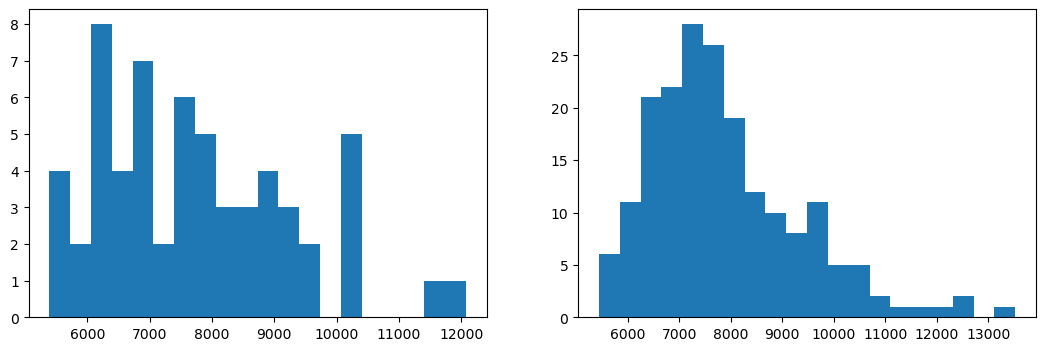

In [43]:
fig, ax = plt.subplots(1,2, figsize = (13,4))
ax[0].hist(D14_pos14_allROIs_concat_filtered["MEAN_INTENSITY_CH1"], 20)
ax[1].hist(D14_pos19_allROIs_concat_filtered["MEAN_INTENSITY_CH1"], 20)

In [45]:
# Creates a table that contains all ROIs of D14

D14_allROIs_concat = pd.concat([D14_pos14_allROIs_concat_filtered, D14_pos19_allROIs_concat_filtered])
D14_allROIs_concat.head()

,TRACK_ID,MEAN_INTENSITY_CH1,NUMBER_SPOTS
0,0,9252.62,11
1,1,8839.63,23
2,2,9134.94,6
3,3,10079.77,11
4,6,10089.87,4


(array([ 9., 16., 28., 30., 29., 34., 25., 17., 15., 11., 12., 10.,  5.,
         3.,  2.,  1.,  2.,  2.,  0.,  1.]),
 array([ 5390.48 ,  5797.067,  6203.654,  6610.241,  7016.828,  7423.415,
         7830.002,  8236.589,  8643.176,  9049.763,  9456.35 ,  9862.937,
        10269.524, 10676.111, 11082.698, 11489.285, 11895.872, 12302.459,
        12709.046, 13115.633, 13522.22 ]),
 <BarContainer object of 20 artists>)

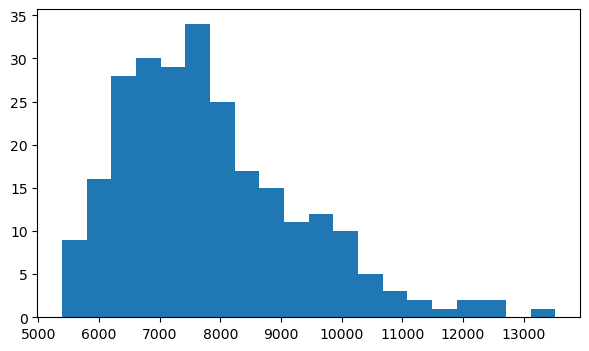

In [47]:
fig, ax = plt.subplots(figsize = (7,4))
ax.hist(D14_allROIs_concat["MEAN_INTENSITY_CH1"], 20)